### Image classification task using the Caltech101 dataset and CNN

### Инициализация

In [ ]:
import os
import keras
import datetime
import numpy as np
import sklearn.metrics
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [ ]:
rng = np.random.default_rng()

In [ ]:
def plot_grid_and_label(dataset: tf.data.Dataset, model: keras.Model | None = None,
                        ncols=2, nrows=2, figsize=(10, 10), hide_axes=True,
                        label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)

    # Создаём новый итератор каждый раз
    iterator = iter(dataset)

    # Берём один батч
    images, labels = next(iterator)

    num_images = nrows * ncols
    images = images[:num_images].numpy()
    labels = labels[:num_images].numpy()

    # --- Если метки one-hot, преобразуем их в индексы ---
    if labels.ndim > 1 and labels.shape[-1] > 1:
        labels = np.argmax(labels, axis=-1)

    images = images.reshape(nrows, ncols, *images.shape[1:])
    labels = labels.reshape(nrows, ncols)

    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])

    if model is not None:
        predictions = np.argmax(model(images.reshape(-1, *images.shape[2:])).numpy(), axis=-1)
        predictions = predictions.reshape(nrows, ncols)
        get_title = lambda i, j: f'label: {map_label(labels[i, j])}, prediction: {map_label(predictions[i, j])}'
    else:
        get_title = lambda i, j: map_label(labels[i, j])

    for i in range(nrows):
        for j in range(ncols):
            ax[i, j].imshow(images[i, j], cmap='gray' if images.shape[-1] == 1 else None)
            ax[i, j].set_title(get_title(i, j))
            if hide_axes:
                ax[i, j].axis('off')


In [ ]:
label_description = [
    'accordion',
    'airplanes',
    'anchor',
    'ant',
    'background_google',
    'barrel',
    'bass',
    'beaver',
    'binocular',
    'bonsai',
    'brain',
    'brontosaurus',
    'buddha',
    'butterfly',
    'camera',
    'cannon',
    'car_side',
    'ceiling_fan',
    'cellphone',
    'chair',
    'chandelier',
    'cougar_body',
    'cougar_face',
    'crab',
    'crayfish',
    'crocodile',
    'crocodile_head',
    'cup',
    'dalmatian',
    'dollar_bill',
    'dolphin',
    'dragonfly',
    'electric_guitar',
    'elephant',
    'emu',
    'euphonium',
    'ewer',
    'faces',
    'faces_easy',
    'ferry',
    'flamingo',
    'flamingo_head',
    'garfield',
    'gerenuk',
    'gramophone',
    'grand_piano',
    'hawksbill',
    'headphone',
    'hedgehog',
    'helicopter',
    'ibis',
    'inline_skate',
    'joshua_tree',
    'kangaroo',
    'ketch',
    'lamp',
    'laptop',
    'leopards',
    'llama',
    'lobster',
    'lotus',
    'mandolin',
    'mayfly',
    'menorah',
    'metronome',
    'minaret',
    'motorbikes',
    'nautilus',
    'octopus',
    'okapi',
    'pagoda',
    'panda',
    'pigeon',
    'pizza',
    'platypus',
    'pyramid',
    'revolver',
    'rhino',
    'rooster',
    'saxophone',
    'schooner',
    'scissors',
    'scorpion',
    'sea_horse',
    'snoopy',
    'soccer_ball',
    'stapler',
    'starfish',
    'stegosaurus',
    'stop_sign',
    'strawberry',
    'sunflower',
    'tick',
    'trilobite',
    'umbrella',
    'watch',
    'water_lilly',
    'wheelchair',
    'wild_cat',
    'windsor_chair',
    'wrench',
    'yin_yang'
]

num_classes = len(label_description)
print(num_classes)

102


### Предобработка

Загрузка датасета

In [ ]:
train_dataset = tfds.load('caltech101', split='train', as_supervised=True)
valid_dataset = tfds.load('caltech101', split='test', as_supervised=True)

In [ ]:
print(train_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


Константы

In [ ]:
num_classes = 102
image_size = (128, 128)
batch_size = 64

Подсчет изображений <br>

Примерно 33% — train, 66% — valid <br>
Обычно используют 80 / 20 %  

In [ ]:
total_train = 0
for image, label in train_dataset:
      total_train += 1


total_valid = 0
for image, label in valid_dataset:
      total_valid += 1

print(f'train {total_train}')
print(f'valid {total_valid}')

train 3060
valid 6084


Кастомное разбиение - неакутально <br>
Посмотри баланс в valid_dataset <br>

In [ ]:
from sklearn.model_selection import train_test_split

images_np = []
labels_np = []

for image, label in tfds.as_numpy(valid_dataset):
    image = tf.image.resize(image, image_size)
    images_np.append(image)
    labels_np.append(label)

images_np = np.array(images_np)
labels_np = np.array(labels_np)


Подсчет дисбаланса классов в тренировочной выборке <br>

Изначальные данные (train_dataset) уже были сбалансированны, <br>
где на каждый класс  отдавалось примерно 0.98% <br>
<br>
Текущие данные несбалансированные - в валидационном датасете
<br>
Минусы - плохая оценка для редких классов <br>
Плюсы - реальные данные тоже несбалансировные

<br>
Всего 102 класса - 1 из которых фон

In [ ]:
counts = { label: np.sum(labels_np == idx) for idx, label in enumerate(label_description) }
total = len(labels_np)

percentages = { label: f'{(count / total * 100):.2f}%' for label, count in counts.items() }
sorted_percentages = dict(sorted(percentages.items(), key=lambda item: item[1]))

print(sorted_percentages)
num_classes = len(np.unique(labels_np))
print(num_classes)

{'inline_skate': '0.02%', 'metronome': '0.03%', 'binocular': '0.05%', 'garfield': '0.07%', 'gerenuk': '0.07%', 'platypus': '0.07%', 'wild_cat': '0.07%', 'octopus': '0.08%', 'snoopy': '0.08%', 'strawberry': '0.08%', 'water_lilly': '0.12%', 'panda': '0.13%', 'okapi': '0.15%', 'scissors': '0.15%', 'wrench': '0.15%', 'mayfly': '0.16%', 'saxophone': '0.16%', 'lobster': '0.18%', 'anchor': '0.20%', 'ant': '0.20%', 'headphone': '0.20%', 'brontosaurus': '0.21%', 'cannon': '0.21%', 'mandolin': '0.21%', 'flamingo_head': '0.25%', 'pigeon': '0.25%', 'stapler': '0.25%', 'beaver': '0.26%', 'barrel': '0.28%', 'ceiling_fan': '0.28%', 'cougar_body': '0.28%', 'pagoda': '0.28%', 'rooster': '0.31%', 'tick': '0.31%', 'camera': '0.33%', 'crocodile': '0.33%', 'crocodile_head': '0.35%', 'gramophone': '0.35%', 'dollar_bill': '0.36%', 'emu': '0.38%', 'pizza': '0.38%', 'bass': '0.39%', 'hedgehog': '0.39%', 'accordion': '0.41%', 'nautilus': '0.41%', 'windsor_chair': '0.43%', 'cup': '0.44%', 'pyramid': '0.44%', 'se

Топ-5 самых частых классов:
airplanes: 770 (12.66%)
motorbikes: 768 (12.62%)
background_google: 437 (7.18%)
faces: 405 (6.66%)
faces_easy: 405 (6.66%)

Топ-5 самых редких классов:
platypus: 4 (0.07%)
wild_cat: 4 (0.07%)
binocular: 3 (0.05%)
metronome: 2 (0.03%)
inline_skate: 1 (0.02%)


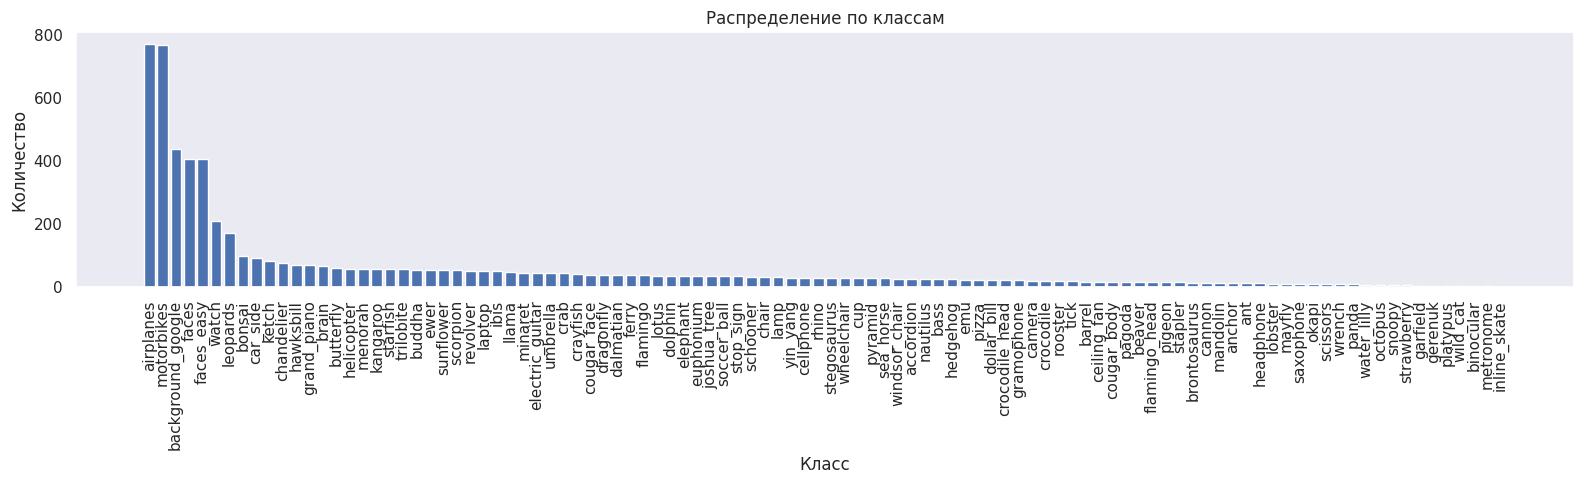

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

counts = {label: np.sum(labels_np == idx) for idx, label in enumerate(label_description)}
total = len(labels_np)
percentages = {label: (count / total * 100) for label, count in counts.items()}
sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))

top_5_most = list(sorted_counts.items())[:5]
top_5_least = list(sorted_counts.items())[-5:]

print("Топ-5 самых частых классов:")
for label, count in top_5_most:
    print(f"{label}: {count} ({percentages[label]:.2f}%)")

print("\nТоп-5 самых редких классов:")
for label, count in top_5_least:
    print(f"{label}: {count} ({percentages[label]:.2f}%)")

plt.figure(figsize=(16,5))
plt.bar(sorted_counts.keys(), sorted_counts.values())
plt.xticks(rotation=90)
plt.title('Распределение по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


Побатчевая предобработка данных

In [ ]:
def resize_and_normalize_image(image: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:

    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),                   # горизонтальное отражение
    keras.layers.RandomRotation(0.025),                       # небольшое вращение
    # keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),  # зум
    # keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # сдвиг
    # keras.layers.RandomContrast(0.1),                        # изменение контрастности
    # keras.layers.RandomBrightness(0.1),                      # изменение яркости
])


def preprocess_train_image(image: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image)
    return image, label

In [ ]:
# def one_hot_encode(image: tf.Tensor, label: tf.Tensor):
#     return image, tf.one_hot(label, num_classes)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# method chaining (цепочка методов)
train_dataset = (
    train_dataset
    # 1. Меняем размер изображения и нормализуем его (0–1 вместо 0–255)
    # .map(resize_and_normalize_image, num_parallel_calls=AUTOTUNE)
    # 3. Применяем аугментации (отражение, поворот, зум) ТОЛЬКО во время тренировки
    # .map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    # .map(one_hot_encode, num_parallel_calls=AUTOTUNE)  # 💡 тут one-hot
    .map(preprocess_train_image)
    # 4. Кэшируем датасет в памяти диск — операции выше будут выполнены только один раз
    # .cache()

    # 5. Перемешиваем данные, чтобы модель не переучивалась на последовательности
    .shuffle(1000)

    # 6. группирует (пакует) данные в батчи, то есть объединяет несколько примеров в один пакет.
    .batch(batch_size)

    # 7. Загружаем следующий батч данных, пока модель работает с текущим
    .prefetch(buffer_size=AUTOTUNE)
)


valid_dataset = (
    valid_dataset
    # .map(resize_and_normalize_image, num_parallel_calls=AUTOTUNE)
    # .map(one_hot_encode, num_parallel_calls=AUTOTUNE)  # 💡 тут one-hot
    # # .cache()
    # .shuffle(1000)
    .map(resize_and_normalize_image)
    .batch(batch_size)
    .prefetch(buffer_size=AUTOTUNE)
    )

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (64, 128, 128, 3)
Label shape: (64,)


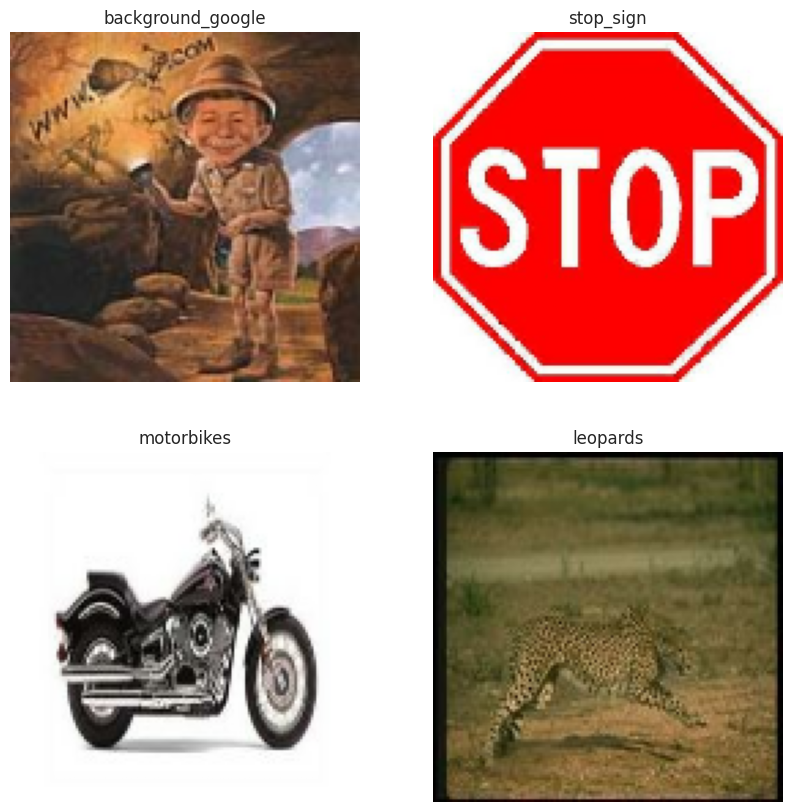

In [ ]:
plot_grid_and_label(valid_dataset, label_description=label_description)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
folder_path_weight = '/content/drive/MyDrive/models/models_weight/'
os.makedirs(folder_path_weight, exist_ok=True)

HISTORY_DIR = '/content/drive/MyDrive/models/history_t1/'
os.makedirs(HISTORY_DIR, exist_ok=True)

logdir = os.path.join(HISTORY_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

Mounted at /content/drive/


### Плоская модель


In [ ]:
inputs = keras.layers.Input(shape=(128, 128, 3), dtype='float32', name="inputs")
x = tf.keras.layers.Flatten()(inputs)

x = tf.keras.layers.Dense(1024)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation(activation='relu', name=('activation_1'))(x)
x = tf.keras.layers.Dropout(0.6)(x)

x = tf.keras.layers.Dense(512)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation(activation='relu', name=('activation_2'))(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = keras.layers.Dense(256)(x)
x = keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation(activation='relu', name=('activation_3'))(x)
x = keras.layers.Dropout(0.4)(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model1 = keras.models.Model(inputs=inputs, outputs=outputs, name='mymodel')
model1.summary()

Model: "mymodel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,022,182 (194.63 MB)

 Trainable params: 51,018,598 (194.62 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='top_1_accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)


In [ ]:
filepath_best_1 = os.path.join(folder_path_weight, "best_model_call1.keras")

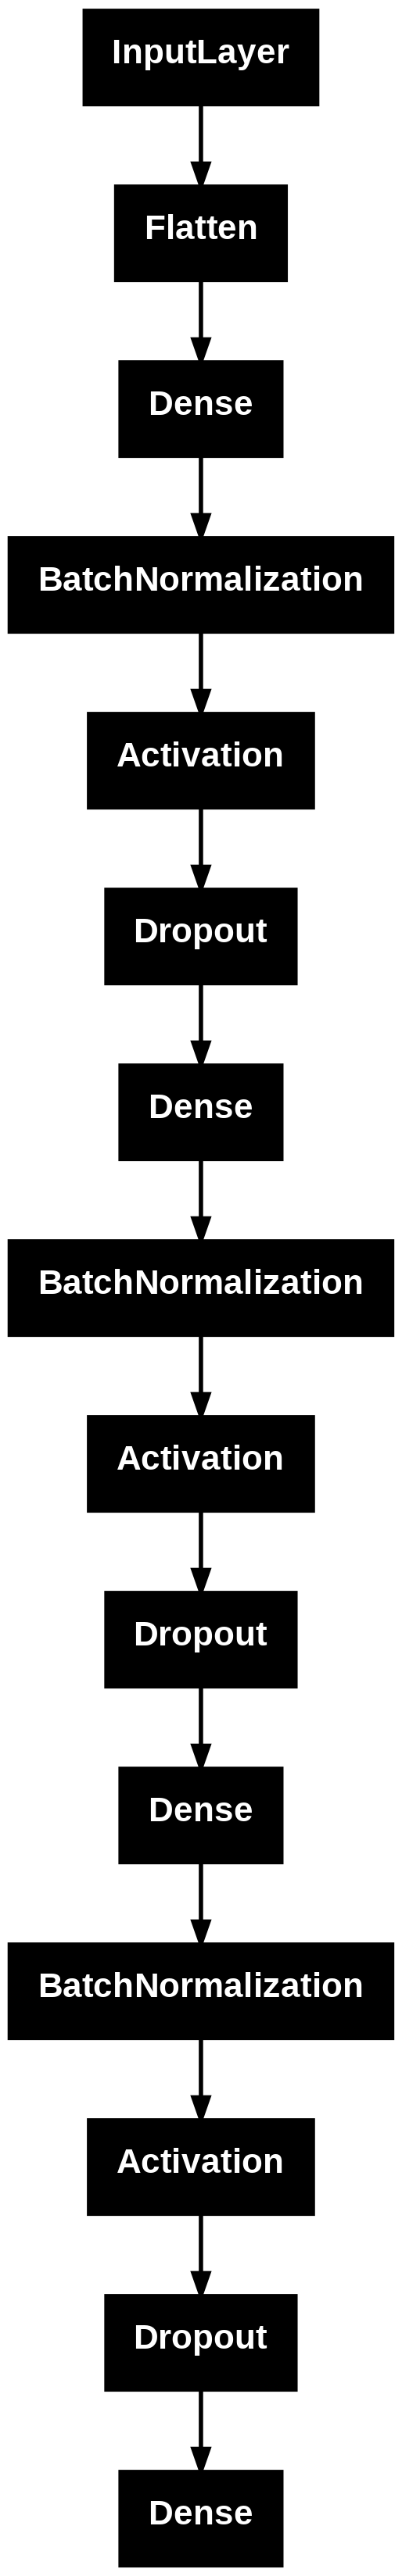

In [ ]:
keras.utils.plot_model(model1)

In [ ]:
callback12 = [
    tf.keras.callbacks.ModelCheckpoint(filepath_best_1 , save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(verbose=1, patience=3, factor=0.5, min_lr=1e-5, monitor='val_loss'),
    tf.keras.callbacks.EarlyStopping(verbose=1, patience=10, restore_best_weights=True),
    tf.keras.callbacks.TensorBoard(log_dir=logdir)
]

In [ ]:
h1 = model1.fit(train_dataset, validation_data=valid_dataset, epochs=20, callbacks=callback12)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 47s 539ms/step - loss: 5.0414 - top_1_accuracy: 0.0160 - top_5_accuracy: 0.0680 - val_loss: 8.6173 - val_top_1_accuracy: 0.0796 - val_top_5_accuracy: 0.1466 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 34s 628ms/step - loss: 4.6366 - top_1_accuracy: 0.0323 - top_5_accuracy: 0.1211 - val_loss: 5.1832 - val_top_1_accuracy: 0.0641 - val_top_5_accuracy: 0.1496 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 56s 929ms/step - loss: 4.3895 - top_1_accuracy: 0.0615 - top_5_accuracy: 0.1833 - val_loss: 4.4227 - val_top_1_accuracy: 0.0521 - val_top_5_accuracy: 0.2230 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 49s 976ms/step - loss: 4.2478 - top_1_accuracy: 0.0809 - top_5_accuracy: 0.2237 - val_loss: 4.0608 - val_top_1_accuracy: 0.1427 - val_top_5_accuracy: 0.3021 - learning_rate: 0.0010
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 80s 928ms/step - loss: 4.1368 - top_1_accuracy: 0.0932 - top_5_accuracy: 0.2524 - val_

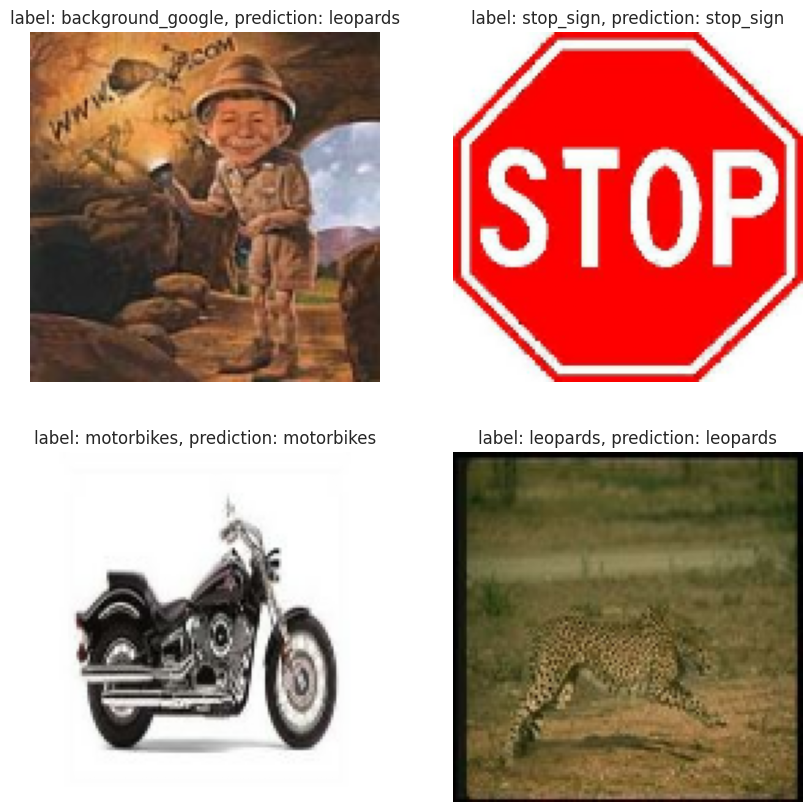

In [ ]:
plot_grid_and_label(valid_dataset, model=model1, label_description=label_description)

In [ ]:
%tensorboard --logdir $logdir

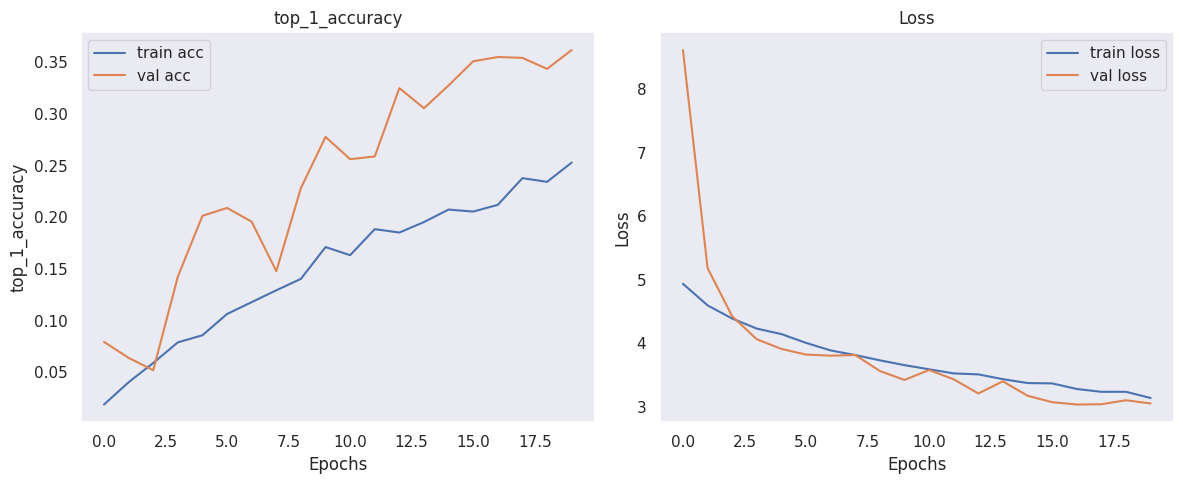

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h1.history['top_1_accuracy'], label='train acc')
plt.plot(h1.history['val_top_1_accuracy'], label='val acc')
plt.title('top_1_accuracy')
plt.xlabel('Epochs')
plt.ylabel('top_1_accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(h1.history['loss'], label='train loss')
plt.plot(h1.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Сверточная модель

---



Глубокая свертка


Каждый из 3 входных каналов обрабатывается своим собственным ядром — то есть:

Канал 1 → проходит свою свёртку

Канал 2 → свою

Канал 3 → свою
Никакое смешивание между каналами не происходит (только потом можно "смешать", если применить pointwise свёртку — 1x1 Conv).


Это сепарабельная свёртка (depthwise separable convolution), которая эффективнее обычной свёртки.


Она разбивает обычную свёртку на два этапа:

Depthwise Convolution — свёртка выполняется отдельно по каждому входному каналу (фильтры с ядром 3x3 применяются к каждому каналу отдельно).

Pointwise Convolution — после этого применяется 1x1 свёртка, которая объединяет каналы и меняет их количество.

Вход — тензор с размерностью (height, width, channels_in)

Сначала depthwise-свёртка «просматривает» каждый канал отдельно, извлекая признаки по пространству (3x3 фильтр на каждом канале).

Затем pointwise-свёртка (1x1 фильтр) смешивает информацию между каналами и формирует новый набор из 128 выходных каналов.



SeparableConv2D обычно значительно экономит вычисления и параметры по сравнению с обычной Conv2D с тем же размером ядра и числом выходных фильтров.

Хорошо подходит для мобильных и эффективных моделей.



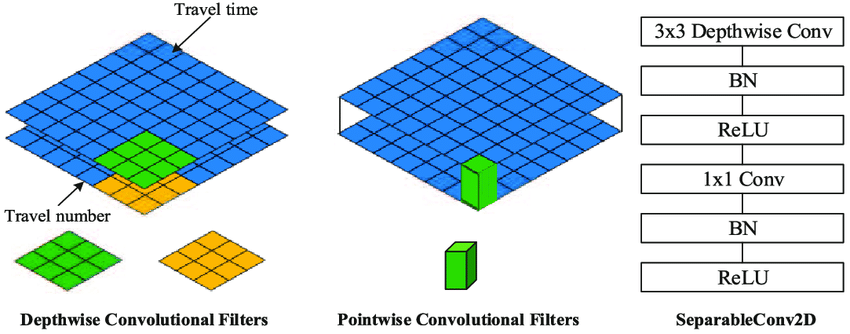

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

inputs = Input(shape=(128, 128, 3))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.1)(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.15)(x)

x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.15)(x)

x = layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(102, activation='softmax')(x)

model2 = models.Model(inputs=inputs, outputs=outputs)


In [ ]:
model2.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_10             │ (None, 16, 16, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,366,470 (16.66 MB)

 Trainable params: 4,365,574 (16.65 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
filepath_best_2 = os.path.join(folder_path_weight, "best_model2_caltech101.keras")

In [ ]:
model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=[
              tf.keras.metrics.SparseCategoricalAccuracy(name='top_1_accuracy'),
              tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
              ]
    )


callback = [
    tf.keras.callbacks.ModelCheckpoint(filepath_best_2, save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(verbose=1, patience=3, factor=0.5, min_lr=1e-6, monitor='val_top_1_accuracy'),
    tf.keras.callbacks.EarlyStopping(verbose=1, patience=20, restore_best_weights=True, monitor='val_top_1_accuracy'),
    tf.keras.callbacks.TensorBoard(log_dir=logdir)
]


In [ ]:
h2 = model2.fit(train_dataset, validation_data=valid_dataset, epochs=100, callbacks=callback)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 568ms/step - loss: 4.9627 - top_1_accuracy: 0.0169 - top_5_accuracy: 0.0587 - val_loss: 4.6416 - val_top_1_accuracy: 0.0062 - val_top_5_accuracy: 0.0209 - learning_rate: 5.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 268ms/step - loss: 4.4575 - top_1_accuracy: 0.0562 - top_5_accuracy: 0.1502 - val_loss: 4.7036 - val_top_1_accuracy: 0.0039 - val_top_5_accuracy: 0.0156 - learning_rate: 5.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 232ms/step - loss: 4.2304 - top_1_accuracy: 0.1007 - top_5_accuracy: 0.2252 - val_loss: 4.6932 - val_top_1_accuracy: 0.0074 - val_top_5_accuracy: 0.0641 - learning_rate: 5.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - loss: 3.9938 - top_1_accuracy: 0.1318 - top_5_accuracy: 0.2941 - val_loss: 4.6631 - val_top_1_accuracy: 0.0066 - val_top_5_accuracy: 0.0480 - learning_rate: 5.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - loss: 3.6160 - top_1_accuracy: 0.2016 - top_5_ac

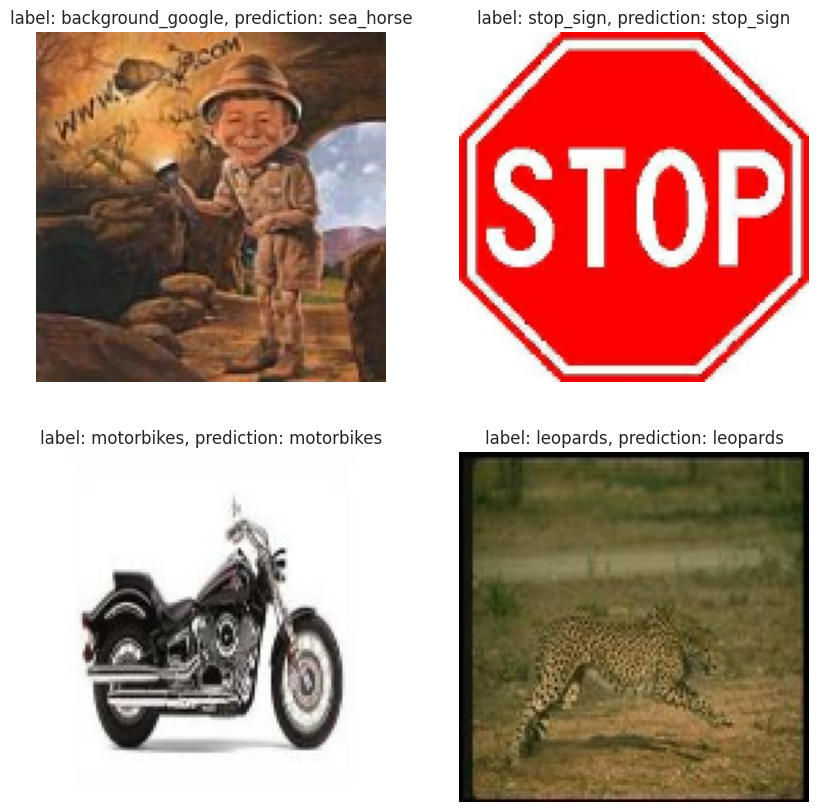

In [ ]:
best_model_2 = tf.keras.models.load_model(filepath_best_2)
plot_grid_and_label(valid_dataset, model=best_model_2, label_description=label_description)

# Testing

Plot confusion matrix. Are there similar classes?

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━

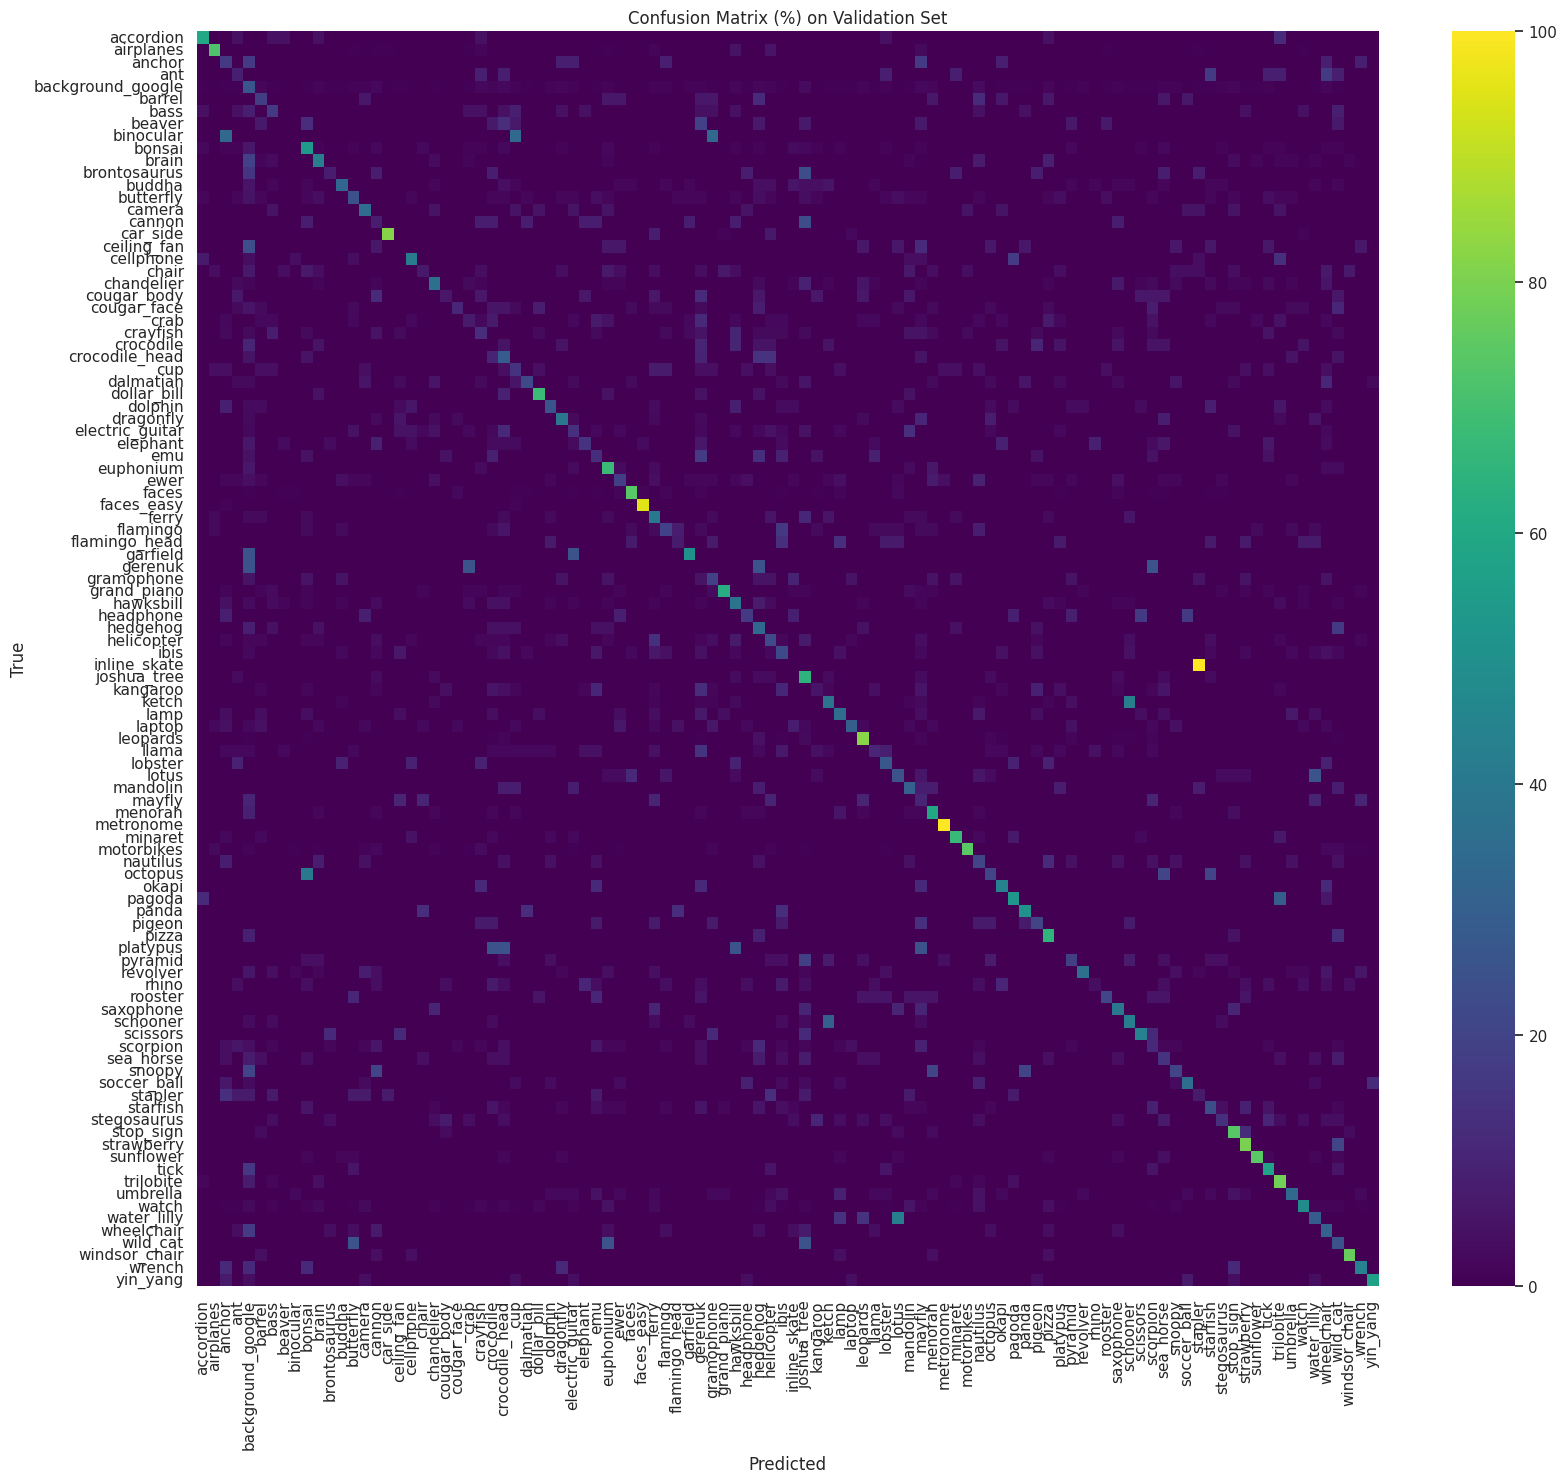

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = []
y_pred = []
for images, labels in valid_dataset:
    preds = best_model_2.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=-1))


y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100 # Приводим к процентам (по строкам)
cm_percent = np.nan_to_num(cm_percent)  # заменяем NaN на 0 (деление на 0)


MAX_CLASSES = 102
if len(cm) > MAX_CLASSES:
    print(f"Слишком много классов ({len(cm)}). Показываем только первые {MAX_CLASSES}.")
    cm_percent = cm_percent[:MAX_CLASSES, :MAX_CLASSES]
    short_labels = label_description[:MAX_CLASSES]
else:
    short_labels = label_description




plt.figure(figsize=(17, 15))
sns.heatmap(cm_percent, annot=False, fmt=".1f", cmap="viridis",
            xticklabels=short_labels, yticklabels=short_labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) on Validation Set")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Порог, выше которого классы считаем "похожими" (в процентах)
threshold = 10.0  # например, если >10% примеров одного класса модель путает с другим

similar_classes = {}
print(cm_percent.shape[0])
print(cm_percent.shape[1])


for i in range(cm_percent.shape[0]):
    similar_to_i = []
    for j in range(cm_percent.shape[1]):
        if i != j and cm_percent[i, j] > threshold:
            similar_to_i.append((j, cm_percent[i, j]))  # (индекс класса, процент ошибок)

    if similar_to_i:
        # Сортируем по степени "путаницы"
        similar_to_i.sort(key=lambda x: -x[1]) # сортирует от самого большого к самому маленькому
        similar_classes[label_description[i]] = [(label_description[j], round(p, 1)) for j, p in similar_to_i] # Сохраняем



for cls, similars in similar_classes.items():
    print(f"Класс '{cls}' часто путают с:")
    for sim_cls, percent in similars:
        print(f"  → {sim_cls} ({percent}%)")
    print()


102
102
Класс 'accordion' часто путают с:
  → trilobite (12.0%)

Класс 'anchor' часто путают с:
  → background_google (16.7%)
  → mayfly (16.7%)

Класс 'ant' часто путают с:
  → starfish (16.7%)
  → wheelchair (16.7%)

Класс 'barrel' часто путают с:
  → hedgehog (11.8%)
  → nautilus (11.8%)

Класс 'beaver' часто путают с:
  → gerenuk (18.8%)
  → bonsai (12.5%)
  → crocodile_head (12.5%)

Класс 'binocular' часто путают с:
  → anchor (33.3%)
  → cup (33.3%)
  → gramophone (33.3%)

Класс 'brain' часто путают с:
  → background_google (19.1%)

Класс 'brontosaurus' часто путают с:
  → joshua_tree (23.1%)
  → background_google (15.4%)

Класс 'cannon' часто путают с:
  → joshua_tree (23.1%)

Класс 'ceiling_fan' часто путают с:
  → background_google (23.5%)
  → mayfly (11.8%)

Класс 'cellphone' часто путают с:
  → pagoda (17.2%)
  → trilobite (13.8%)

Класс 'cougar_body' часто путают с:
  → cannon (11.8%)
  → gerenuk (11.8%)

Класс 'cougar_face' часто путают с:
  → wild_cat (10.3%)

Класс 'crab

Get some images from the internet. Do they belong to correct classes according to the model?

Ошибка при загрузке https://zastavki.gas-kvas.com/uploads/posts/2024-09/zastavki-gas-kvas-com-wm0t-p-zastavki-na-telefon-oruzhie-1.jpg:
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


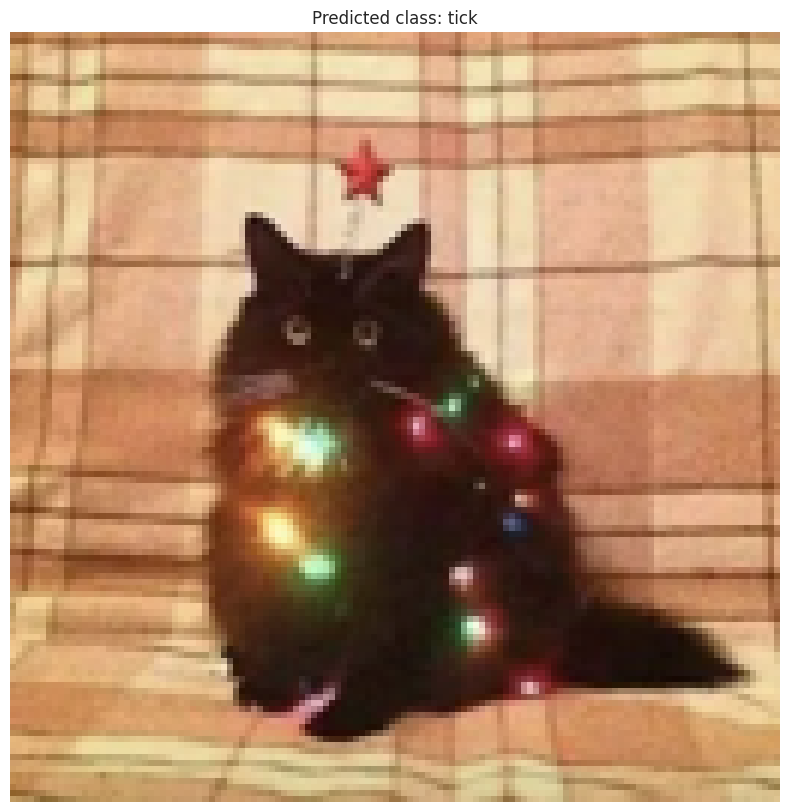

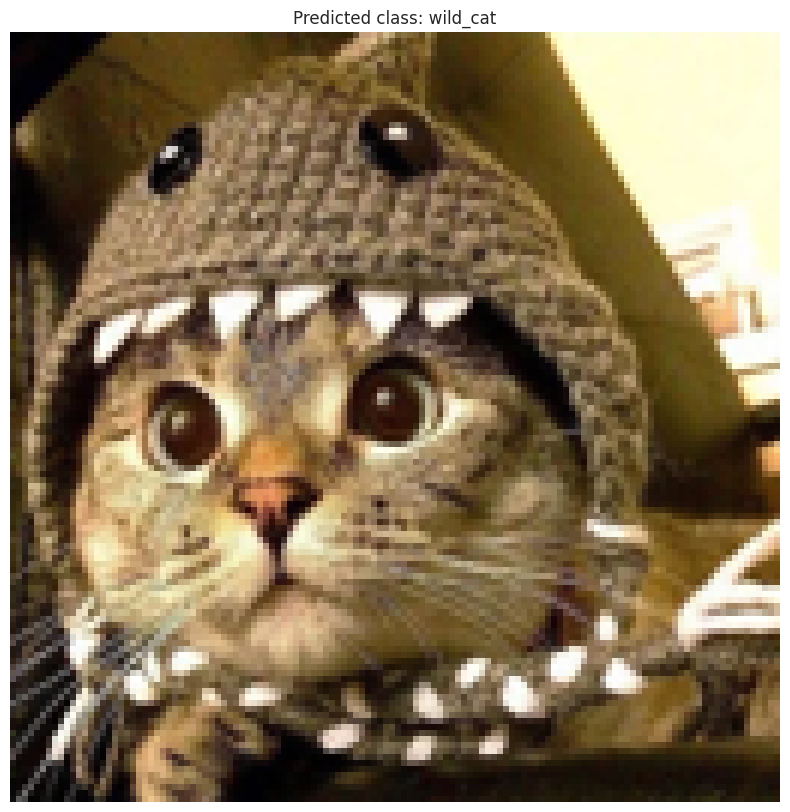

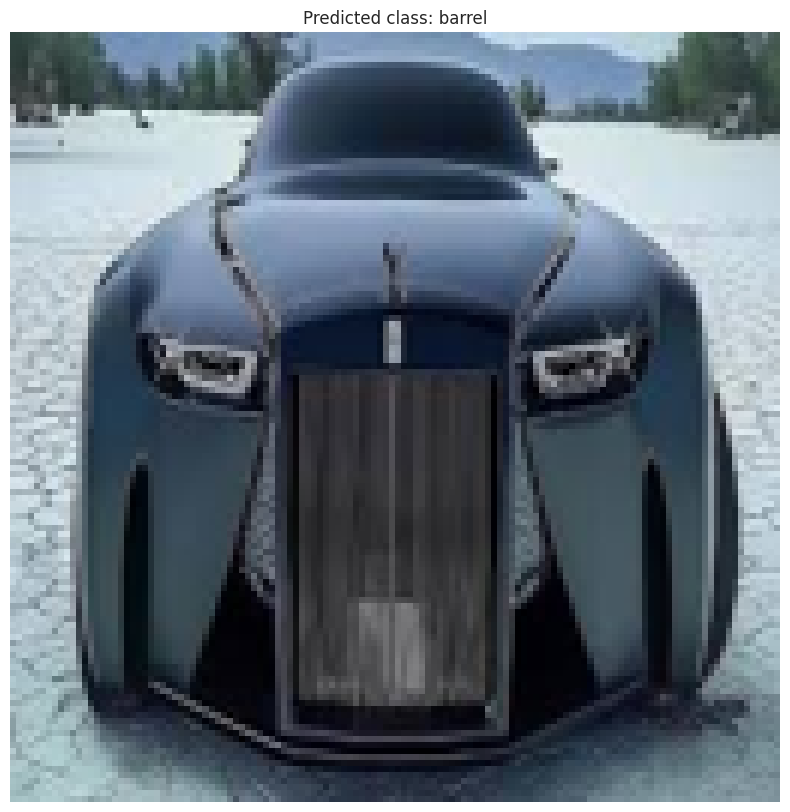

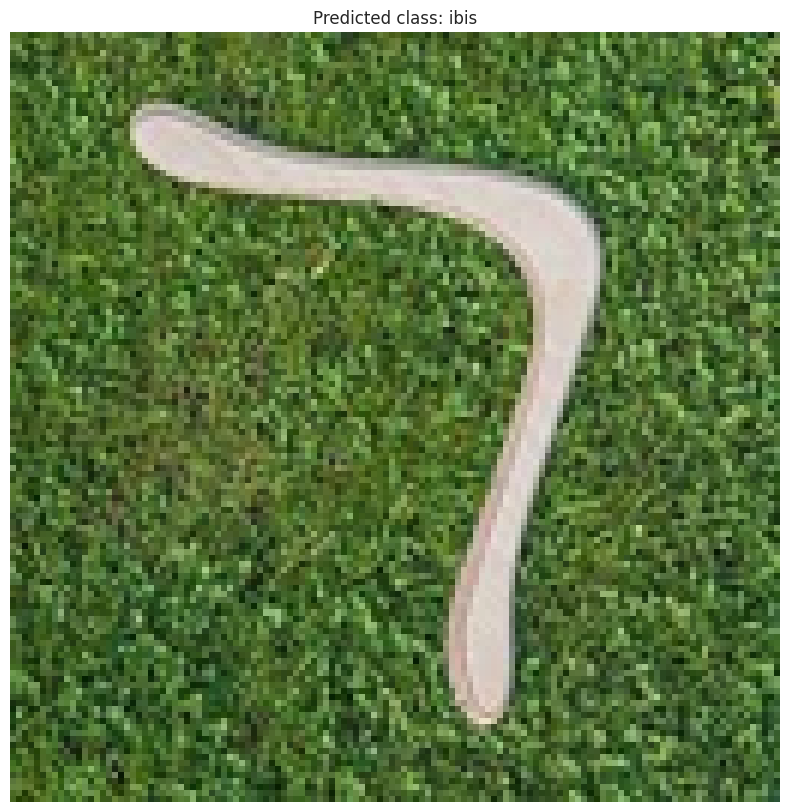

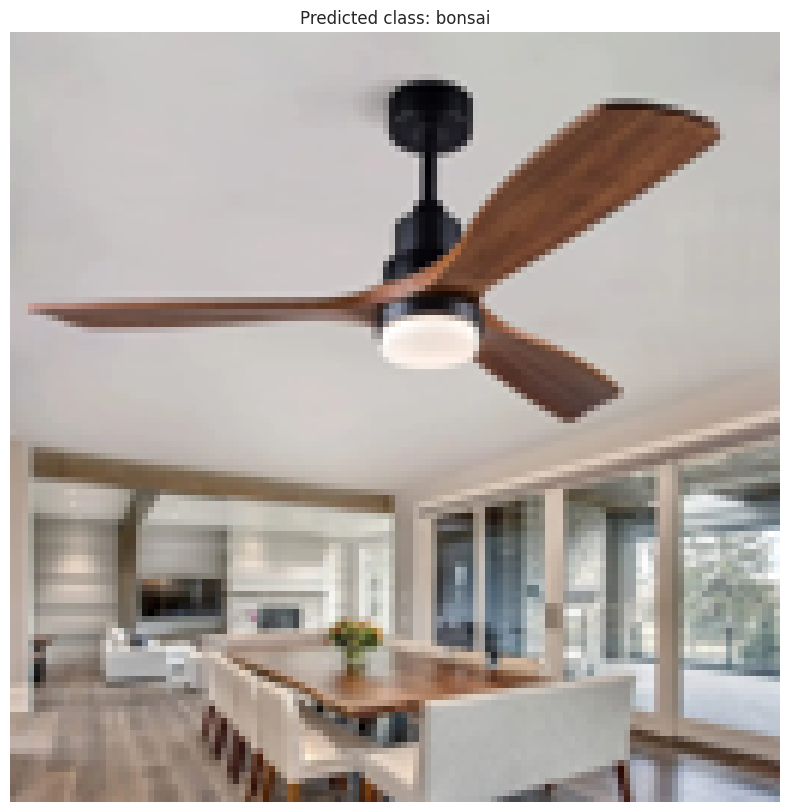

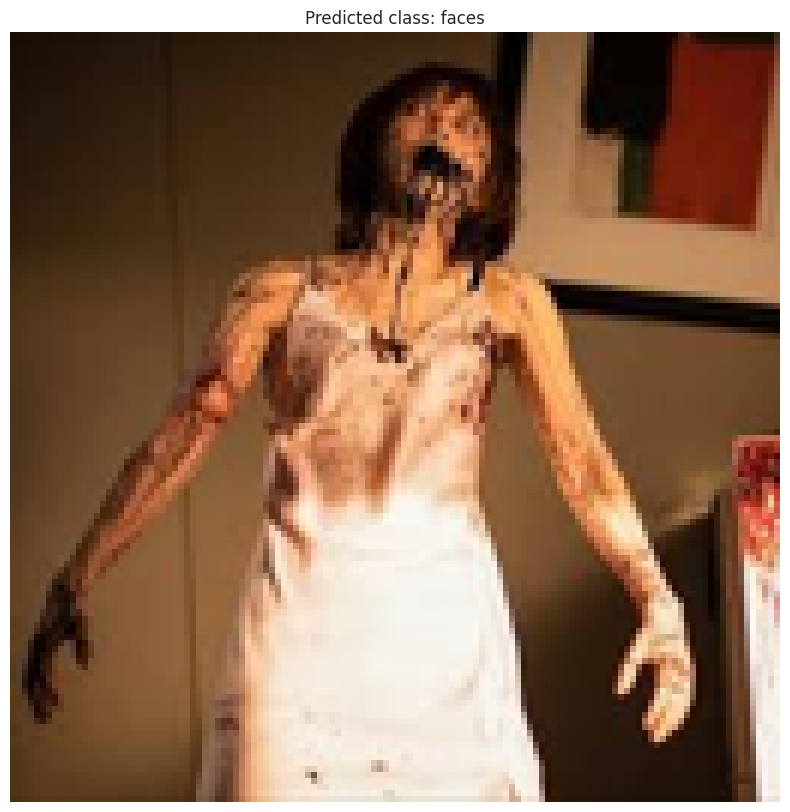

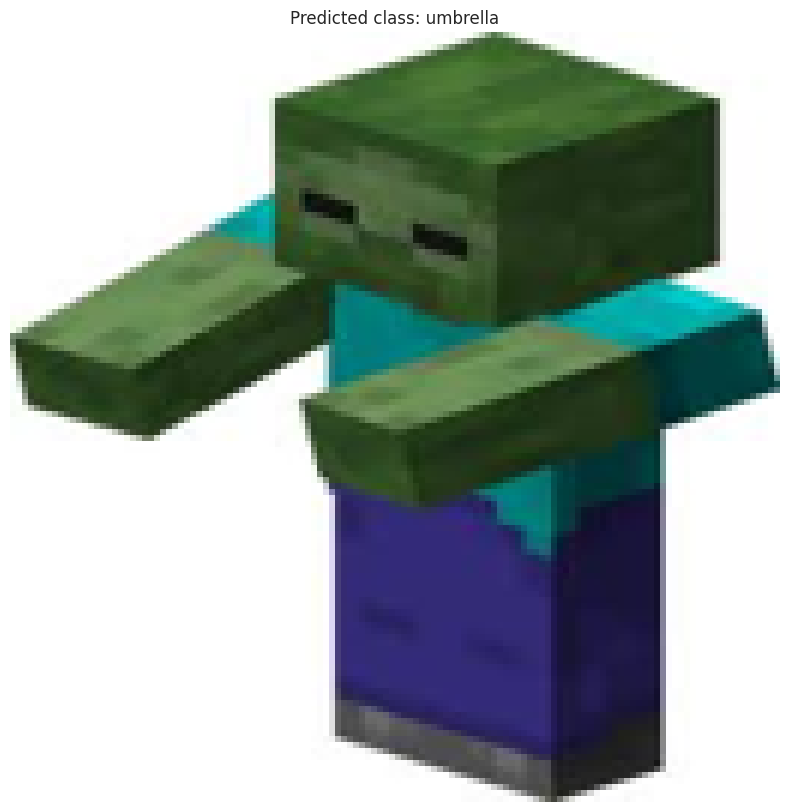

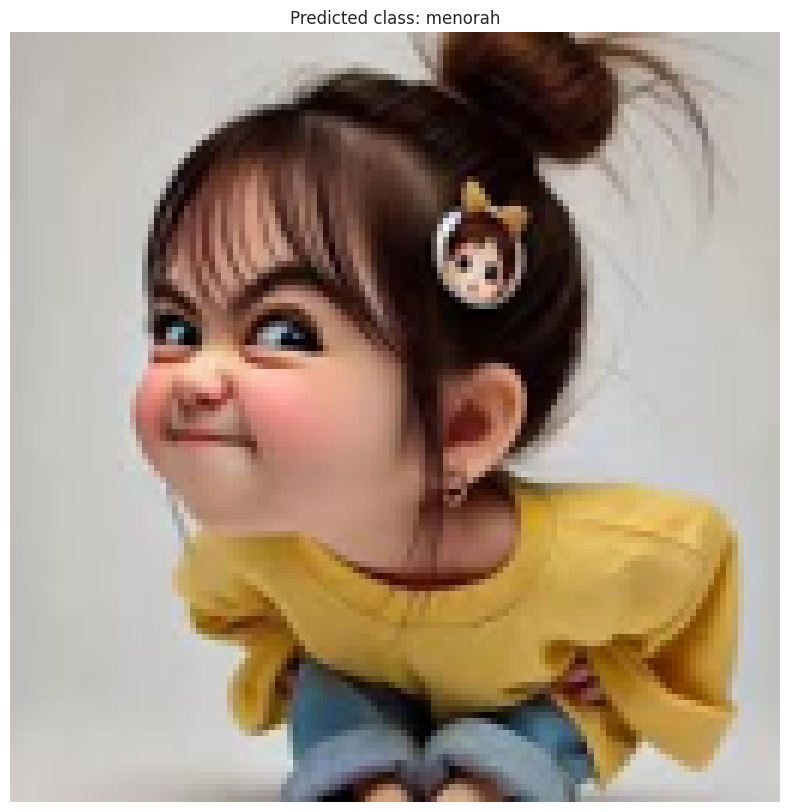

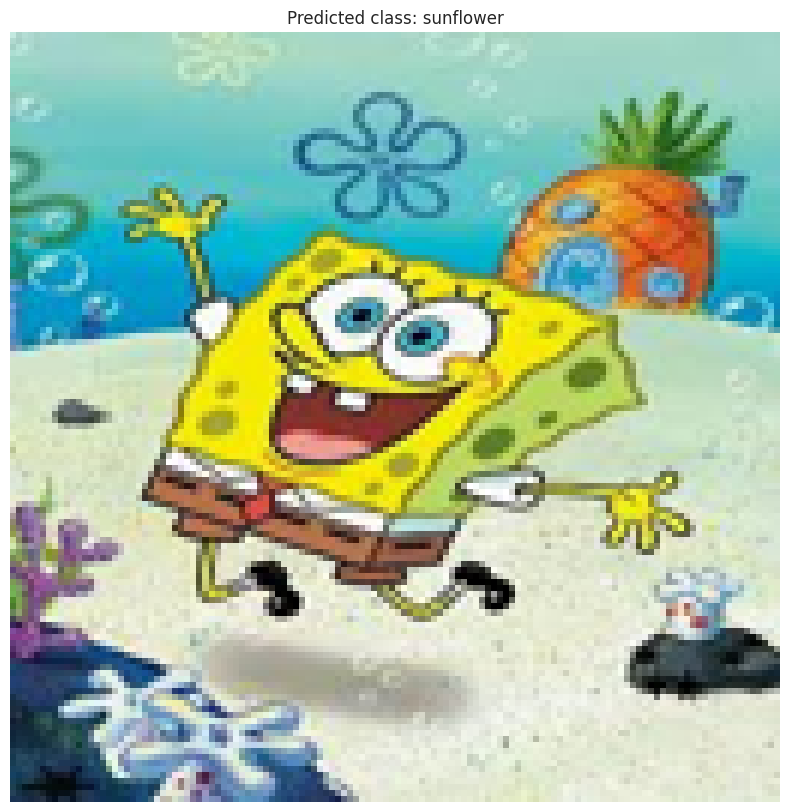

In [ ]:
import requests  # для скачивания файлов из интернета
from PIL import Image  # для работы с изображениями (открытие, изменение размера)
from io import BytesIO  # чтобы из байтов создать "файл" для PIL

urls = [
    'https://images.techinsider.ru/upload/img_cache/c59/c591539a15f5b2564a6b2fae4ec6495c_cropped_564x564.webp',
    'https://images.techinsider.ru/upload/img_cache/b76/b76137ebad1c1cee0359a993137c28a7_cropped_666x642.webp',
    'https://zastavki.gas-kvas.com/uploads/posts/2024-09/zastavki-gas-kvas-com-wm0t-p-zastavki-na-telefon-oruzhie-1.jpg',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT3Ga33ctnrWYLv1mxaN42zNsRVkW42DZ_1Gg&s',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSV1QfRVTeyXyOYFUSEVeP96g23I1jVTnSqMg&s',
    'https://ae04.alicdn.com/kf/Sb1f65fe707e546009c92b9cb7fb6cec24.jpg',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTonsTkQx6bvjqEff_4huKScw98CcHlmQPvXQ&s',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRVG36hiWafvluiZqb8XWQb4iA79uD3O0oBbw&s',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ94AOxUDExvOeJ_VNTDnEM2wZ0KQZX0QT0GQ&s',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTi3vlT5dDAjGcfFMvv4WTu5P-go2UphNmvbQ&s'
]

images = []

for url in urls:
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # выбросит исключение при ошибке HTTP
        img = Image.open(BytesIO(response.content)).convert('RGB')
        images.append(img)
    except Exception as e:
        print(f"Ошибка при загрузке {url}:\n{e}")

#---------------------------------------------------------

def preprocess(img):
    img = img.resize((128, 128))
    img = np.array(img) / 255.0
    return img

processed_images = np.array([preprocess(img) for img in images])
preds = best_model_2.predict(processed_images)
predicted_classes = np.argmax(preds, axis=1)


for i, img in enumerate(processed_images):
    plt.imshow(img)
    plt.axis('off')
    pred_label = label_description[predicted_classes[i]]
    plt.title(f"Predicted class: {pred_label}")
    plt.show()
